In [15]:
import requests
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
import re
import warnings
import time

# SSL警告を非表示にする
warnings.filterwarnings("ignore", category=UserWarning, module="urllib3")

def clean_passengers(val):
    """注釈、単位、パーセントを徹底除去して純粋な数値にする"""
    if pd.isna(val): return 0
    s = str(val).split('[')[0].split('(')[0].split('%')[0]
    s = re.sub(r'\D', '', s)
    try:
        return int(s)
    except:
        return 0

class TransportScraper:
    def __init__(self, url):
        self.url = url
        self.headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)'}

    def fetch_airport_data(self, limit=50):
        print(f"--- Wikipediaからデータ取得中 ---")
        time.sleep(1) 
        resp = requests.get(self.url, headers=self.headers)
        resp.raise_for_status()
        
        tables = pd.read_html(StringIO(resp.text))
        
        # 適切なテーブルを探す
        df_target = None
        for t in tables:
            cols_str = "".join([str(c) for c in t.columns.get_level_values(-1)]).lower()
            if 'airport' in cols_str and 'passengers' in cols_str:
                df_target = t
                break
        
        if df_target is None:
            raise ValueError("適切なデータテーブルが見つかりませんでした。")

        if isinstance(df_target.columns, pd.MultiIndex):
            df_target.columns = df_target.columns.get_level_values(-1)

        # 列の抽出
        res_df = pd.DataFrame()
        for col in df_target.columns:
            c_low = str(col).lower()
            if 'airport' in c_low and 'rank' not in c_low: res_df['airport'] = df_target[col]
            if 'location' in c_low: res_df['location'] = df_target[col]
            if 'passenger' in c_low and 'rank' not in c_low: res_df['total_passengers'] = df_target[col]

        df = res_df.copy()
        df['total_passengers'] = df['total_passengers'].apply(clean_passengers)
        
        # 【修正ポイント】国名の抽出精度向上：アメリカの州名や中国の地域名を国名に置換
        def extract_country(loc):
            parts = [p.strip() for p in str(loc).split(',')]
            last_part = parts[-1]
            
            # アメリカのキーワード補正
            us_keywords = ['Texas', 'Georgia', 'California', 'Florida', 'Illinois', 'Colorado', 'USA', 'United States']
            if any(key in last_part for key in us_keywords) or len(parts) == 2:
                return 'United States'
            
            # 中国のキーワード補正
            china_keywords = ['Guangdong', 'Shanghai', 'Yunnan', 'Chongqing', 'Beijing', 'China']
            if any(key in last_part for key in china_keywords):
                return 'China'
                
            return last_part

        df['country'] = df['location'].apply(extract_country)
        
        # 数値が正常（100万人以上）なものだけを抽出
        df = df[df['total_passengers'] > 1000000].sort_values('total_passengers', ascending=False)
        print(f"データ取得完了。有効件数: {len(df)}件")
        return df.head(limit)

class TransportDatabase:
    def __init__(self, db_name='transport_data.db'):
        self.db_name = db_name

    def save_to_db(self, df):
        with sqlite3.connect(self.db_name) as conn:
            df.to_sql('airports', conn, if_exists='replace', index=False)
            print(f"DBに {len(df)} 件のデータを保存しました。")

    def get_data_by_country(self, country=""):
        conn = sqlite3.connect(self.db_name)
        if country == "":
            query = "SELECT * FROM airports ORDER BY total_passengers DESC"
            df = pd.read_sql(query, conn)
        else:
            query = "SELECT * FROM airports WHERE country LIKE ? ORDER BY total_passengers DESC"
            df = pd.read_sql(query, conn, params=(f"%{country}%",))
        conn.close()
        return df

    def get_unique_countries(self):
        with sqlite3.connect(self.db_name) as conn:
            res = conn.execute("SELECT DISTINCT country FROM airports").fetchall()
            return [r[0] for r in res]

class TransportAnalyzer:
    @staticmethod
    def get_region(country):
        # 【修正ポイント】地域判定辞書
        mapping = {
            'United States': 'North America', 
            'China': 'Asia', 
            'Japan': 'Asia',
            'South Korea': 'Asia', 
            'Republic of Korea': 'Asia',
            'India': 'Asia', 
            'Thailand': 'Asia',
            'Singapore': 'Asia',
            'United Arab Emirates': 'Middle East', 
            'Qatar': 'Middle East',
            'United Kingdom': 'Europe', 
            'France': 'Europe', 
            'Germany': 'Europe',
            'Spain': 'Europe',
            'Netherlands': 'Europe',
            'Turkey': 'Europe/Middle East'
        }
        return mapping.get(country, 'Others')

    @staticmethod
    def plot_airport_ranking(df, search_term):
        if df.empty:
            print("表示できるデータがありませんでした。")
            return
        df = df.copy()
        df['passengers_m'] = df['total_passengers'] / 1_000_000
        plt.figure(figsize=(10, 8))
        bars = plt.barh(df['airport'], df['passengers_m'], color='teal', alpha=0.7)
        plt.xlabel('Annual Passengers (Millions)')
        plt.title(f'Busiest Airports Analysis: {search_term if search_term else "Top List"}')
        plt.gca().invert_yaxis()
        plt.grid(axis='x', linestyle='--', alpha=0.6)
        for bar in bars:
            width = bar.get_width()
            plt.text(width, bar.get_y() + bar.get_height()/2, f' {width:.1f}M', va='center')
        plt.tight_layout()
        plt.show()

In [16]:
wiki_url = "https://en.wikipedia.org/wiki/List_of_busiest_airports_by_passenger_traffic"
try:
    scraper = TransportScraper(wiki_url)
    airport_data = scraper.fetch_airport_data(limit=50)
    db_manager = TransportDatabase()
    db_manager.save_to_db(airport_data)
    print("\n--- 正確な数値と国名でDBを更新しました ---")
    display(airport_data.head()) 
except Exception as e:
    print(f"エラーが発生しました: {e}")

--- Wikipediaからデータ取得中 ---
データ取得完了。有効件数: 23件
DBに 23 件のデータを保存しました。

--- 正確な数値と国名でDBを更新しました ---


,airport,location,total_passengers,country
2,Dallas Fort Worth International Airport,"Dallas–Fort Worth, Texas",85660127,United States
4,Shanghai Pudong International Airport,"Pudong, Shanghai",84939600,United States
5,Heathrow Airport,"Hillingdon, London",84463000,United States
6,Istanbul Airport,"Arnavutköy, Istanbul",84457421,United States
7,Guangzhou Baiyun International Airport,"Baiyun-Huadu, Guangzhou, Guangdong",83587749,China


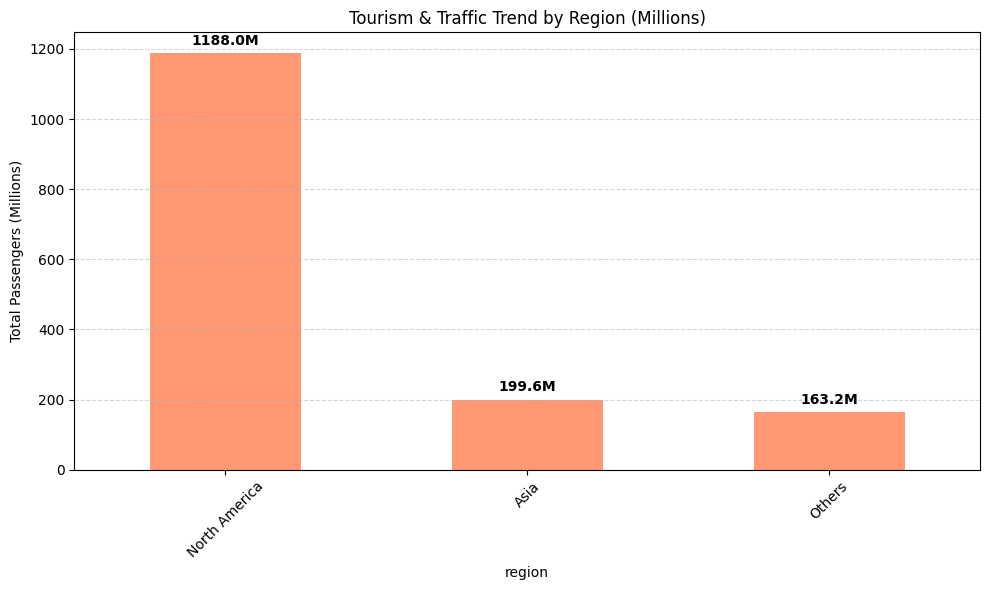

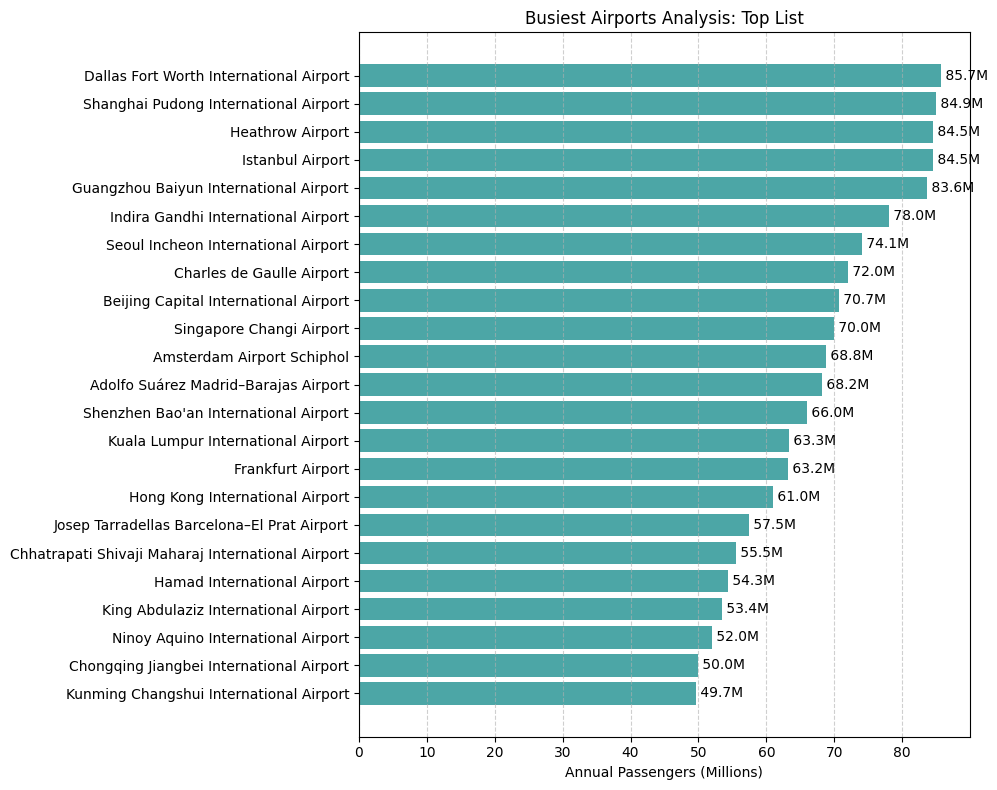

In [17]:
db = TransportDatabase()
df_all = db.get_data_by_country("")

if not df_all.empty:
    # 地域判定を適用
    df_all['region'] = df_all['country'].apply(TransportAnalyzer.get_region)
    
    # 地域別ランキングの集計
    region_summary = df_all.groupby('region')['total_passengers'].sum() / 1_000_000
    region_summary = region_summary.sort_values(ascending=False)
    
    # グラフ表示
    plt.figure(figsize=(10, 6))
    ax = region_summary.plot(kind='bar', color='coral', alpha=0.8)
    plt.title('Tourism & Traffic Trend by Region (Millions)')
    plt.ylabel('Total Passengers (Millions)')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    for i, v in enumerate(region_summary):
        plt.text(i, v + (region_summary.max()*0.02), f"{v:.1f}M", ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

    # 個別の空港ランキングも表示
    target = input("\n個別のランキングを表示したい国名を入力してください（空欄で全表示）: ").strip()
    filtered_df = db.get_data_by_country(target)
    TransportAnalyzer.plot_airport_ranking(filtered_df, target)
else:
    print("データがありません。セル2を実行してください。")